Modélisation par Arbre de Décision (Decision Tree) — Malak Achari

Dans cette partie, nous appliquons l’algorithme Arbre de Décision (Decision Tree) pour prédire la classe énergétique d’un bâtiment à partir des caractéristiques géométriques et physiques du dataset (surface_area, wall_area, roof_area, glazing_area, height, compactness, orientation).

L’objectif principal est de construire un modèle performant mais aussi généralisable, en évitant le surapprentissage (overfitting), qui est fréquent avec les arbres trop profonds. Pour cela, nous utilisons une stratégie d’élagage basée sur la profondeur maximale (max_depth) et nous sélectionnons la profondeur optimale en utilisant la validation croisée.

Les données utilisées proviennent de la phase d’exploration/préparation précédente, et nous conservons le même protocole de séparation train/test afin d’assurer une comparaison équitable avec les autres modèles (KNN, SVM RBF, etc.).

Objectifs

Appliquer un modèle d’arbre de décision pour la classification énergétique.

Analyser l’impact de la profondeur (max_depth) sur les performances (train vs test) afin d’identifier l’overfitting / underfitting.

Choisir automatiquement la profondeur optimale via la validation croisée (plus fiable qu’un seul split).

Évaluer le modèle final avec les métriques demandées (Accuracy, Precision, Recall, F1-score) et interpréter les résultats.

Interpréter le comportement du modèle à l’aide de courbes et de la matrice de confusion, et éventuellement visualiser l’arbre final.



Étapes de la modélisation par Arbre de Décision (selon notre démarche)

Chargement et préparation des données

Import des bibliothèques

Lecture du dataset

Séparation features/target

Séparation Train/Test (protocole commun)

Split stratifié pour conserver la répartition des classes

Le test est réservé pour l’évaluation finale

Évaluation sur plusieurs profondeurs (diagnostic)

Entraîner plusieurs arbres avec max_depth différent

Calculer les métriques sur train et test

Présenter les résultats sous forme de tableau comparatif

Identifier à partir de quelle profondeur apparaît l’overfitting

Choix de la profondeur optimale par validation croisée

Appliquer une Stratified K-Fold CV sur le train

Comparer les profondeurs avec un score principal (F1-macro)

Sélectionner la profondeur qui généralise le mieux

Entraînement du modèle optimal + évaluation finale

Ré-entraîner l’arbre avec la profondeur optimale sur tout le train

Évaluer une seule fois sur le test (métriques + matrice de confusion)

Validation finale du comportement (under/overfitting)

Graphiques de comparaison (train vs CV vs test)

Conclusion et justification des choix

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("../data/energy_dataset.csv")
df.head()


,surface_area,wall_area,roof_area,glazing_area,height,compactness,orientation,energy_class
0,274,378,272,19,4.702751,0.530007,4,1
1,339,359,175,18,4.972581,0.817926,1,0
2,314,297,140,17,3.809120,0.644334,2,0
3,332,448,170,17,5.141293,0.680344,4,0
4,313,342,260,28,4.652013,0.756585,2,1


In [10]:
X = df.drop(columns=["energy_class"])
y = df["energy_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Répartition classes (train):")
print(y_train.value_counts(normalize=True).round(3))
print("Répartition classes (test):")
print(y_test.value_counts(normalize=True).round(3))


Train: (4000, 7) Test: (1000, 7)
Répartition classes (train):
energy_class
0    0.569
1    0.371
2    0.060
Name: proportion, dtype: float64
Répartition classes (test):
energy_class
0    0.569
1    0.371
2    0.060
Name: proportion, dtype: float64


In [11]:
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)

pred_tr = dt_overfit.predict(X_train)
pred_te = dt_overfit.predict(X_test)

print("Accuracy Train:", accuracy_score(y_train, pred_tr))
print("Accuracy Test :", accuracy_score(y_test, pred_te))
print("Profondeur:", dt_overfit.get_depth(), "| Feuilles:", dt_overfit.get_n_leaves())


Accuracy Train: 1.0
Accuracy Test : 0.807
Profondeur: 19 | Feuilles: 479


In [12]:
depths = range(1, 21)

rows = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    ytr = dt.predict(X_train)
    yte = dt.predict(X_test)

    rows.append({
        "max_depth": d,
        "acc_train": accuracy_score(y_train, ytr),
        "acc_test": accuracy_score(y_test, yte),

        # macro = chaque classe compte pareil (utile si classes déséquilibrées)
        "prec_train": precision_score(y_train, ytr, average="macro", zero_division=0),
        "prec_test":  precision_score(y_test,  yte, average="macro", zero_division=0),
        "rec_train":  recall_score(y_train, ytr, average="macro", zero_division=0),
        "rec_test":   recall_score(y_test,  yte, average="macro", zero_division=0),
        "f1_train":   f1_score(y_train, ytr, average="macro"),
        "f1_test":    f1_score(y_test,  yte, average="macro"),

        "depth_real": dt.get_depth(),
        "leaves": dt.get_n_leaves()
    })

df_split = pd.DataFrame(rows)
df_split.sort_values("f1_test", ascending=False).head(10)


,max_depth,acc_train,acc_test,prec_train,prec_test,rec_train,rec_test,f1_train,f1_test,depth_real,leaves
6,7,0.90225,0.847,0.836152,0.757844,0.853894,0.750894,0.844518,0.753822,7,108
3,4,0.86675,0.851,0.791780,0.753515,0.773531,0.751707,0.780480,0.751389,4,16
4,5,0.87075,0.850,0.794157,0.752088,0.773685,0.748620,0.782502,0.749800,5,32
5,6,0.88300,0.850,0.816735,0.756174,0.785433,0.720020,0.799434,0.735158,6,62
9,10,0.96225,0.830,0.943125,0.720630,0.918076,0.727244,0.929297,0.723700,10,312
7,8,0.92475,0.838,0.884356,0.734219,0.856934,0.709271,0.868975,0.719574,8,171
10,11,0.97425,0.821,0.965471,0.704184,0.943359,0.708593,0.953581,0.706338,11,364
16,17,0.99875,0.815,0.999190,0.697673,0.998955,0.716861,0.999072,0.706090,17,472
8,9,0.94325,0.824,0.913813,0.721263,0.884330,0.695787,0.897305,0.705683,9,243
13,14,0.99300,0.813,0.994024,0.694129,0.986968,0.706375,0.990403,0.699771,14,447


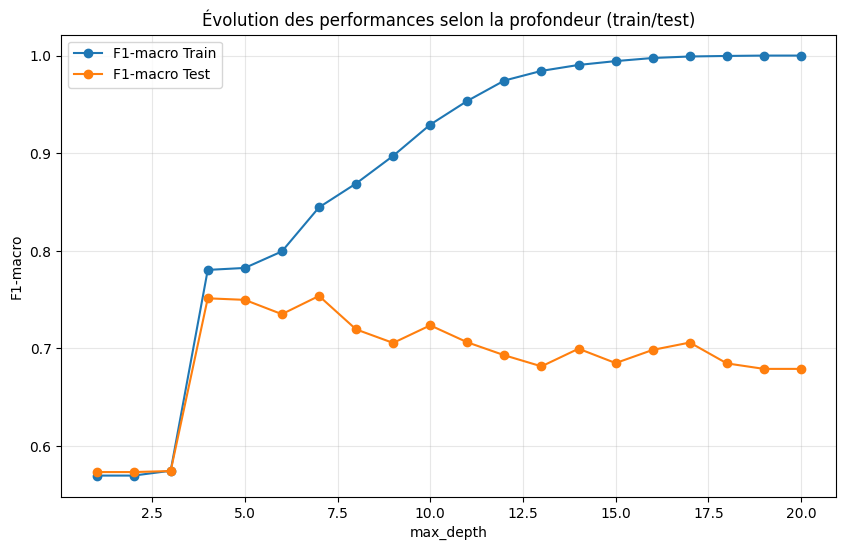

In [13]:
plt.figure(figsize=(10,6))
plt.plot(df_split["max_depth"], df_split["f1_train"], marker="o", label="F1-macro Train")
plt.plot(df_split["max_depth"], df_split["f1_test"],  marker="o", label="F1-macro Test")
plt.xlabel("max_depth")
plt.ylabel("F1-macro")
plt.title("Évolution des performances selon la profondeur (train/test)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows_cv = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)

    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring="f1_macro")
    rows_cv.append({
        "max_depth": d,
        "mean_cv_f1": scores.mean(),
        "std_cv_f1": scores.std()
    })

df_cv = pd.DataFrame(rows_cv)
df_cv.sort_values("mean_cv_f1", ascending=False).head(10)


,max_depth,mean_cv_f1,std_cv_f1
3,4,0.767549,0.042915
5,6,0.745316,0.049683
6,7,0.742796,0.044128
4,5,0.737108,0.012947
7,8,0.722141,0.037415
9,10,0.720677,0.028272
8,9,0.720091,0.028353
10,11,0.711570,0.026062
12,13,0.704066,0.019753
11,12,0.703677,0.020434


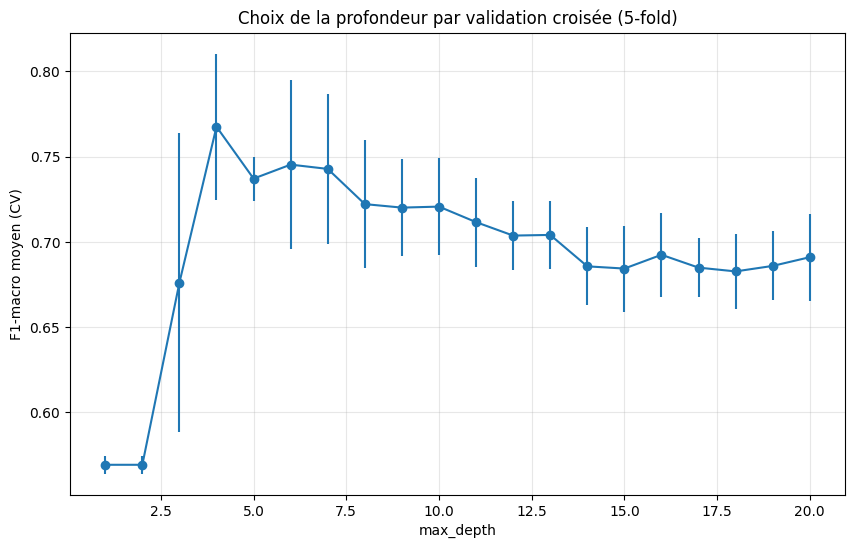

Profondeur optimale (selon CV): 4


In [15]:
plt.figure(figsize=(10,6))
plt.errorbar(df_cv["max_depth"], df_cv["mean_cv_f1"], yerr=df_cv["std_cv_f1"], marker="o")
plt.xlabel("max_depth")
plt.ylabel("F1-macro moyen (CV)")
plt.title("Choix de la profondeur par validation croisée (5-fold)")
plt.grid(True, alpha=0.3)
plt.show()

best_depth = int(df_cv.loc[df_cv["mean_cv_f1"].idxmax(), "max_depth"])
print("Profondeur optimale (selon CV):", best_depth)


In [16]:
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)

y_pred = dt_final.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision macro:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("Recall macro   :", recall_score(y_test, y_pred, average="macro", zero_division=0))
print("F1 macro       :", f1_score(y_test, y_pred, average="macro"))

print("\nMatrice de confusion:\n", confusion_matrix(y_test, y_pred))
print("\nRapport détaillé:\n", classification_report(y_test, y_pred, digits=4))


Accuracy : 0.851
Precision macro: 0.7535154760174896
Recall macro   : 0.7517070452989145
F1 macro       : 0.7513887474807014

Matrice de confusion:
 [[503  66   0]
 [ 28 317  26]
 [  0  29  31]]

Rapport détaillé:
               precision    recall  f1-score   support

           0     0.9473    0.8840    0.9145       569
           1     0.7694    0.8544    0.8097       371
           2     0.5439    0.5167    0.5299        60

    accuracy                         0.8510      1000
   macro avg     0.7535    0.7517    0.7514      1000
weighted avg     0.8571    0.8510    0.8526      1000



C:\Users\malak\AppData\Local\Temp\ipykernel_26612\1272003727.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  f1_cv_final = float(df_cv[df_cv["max_depth"] == best_depth]["mean_cv_f1"])


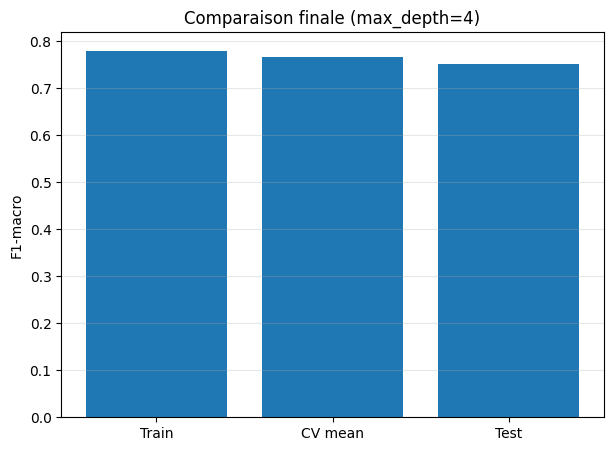

F1 Train: 0.7804797418266611
F1 CV   : 0.7675494215127181
F1 Test : 0.7513887474807014


In [17]:
# Score train (F1)
ytr_final = dt_final.predict(X_train)
f1_train_final = f1_score(y_train, ytr_final, average="macro")

# Score CV (moyenne) pour best_depth
f1_cv_final = float(df_cv[df_cv["max_depth"] == best_depth]["mean_cv_f1"])

# Score test (F1)
f1_test_final = f1_score(y_test, y_pred, average="macro")

plt.figure(figsize=(7,5))
plt.bar(["Train", "CV mean", "Test"], [f1_train_final, f1_cv_final, f1_test_final])
plt.ylabel("F1-macro")
plt.title(f"Comparaison finale (max_depth={best_depth})")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print("F1 Train:", f1_train_final)
print("F1 CV   :", f1_cv_final)
print("F1 Test :", f1_test_final)


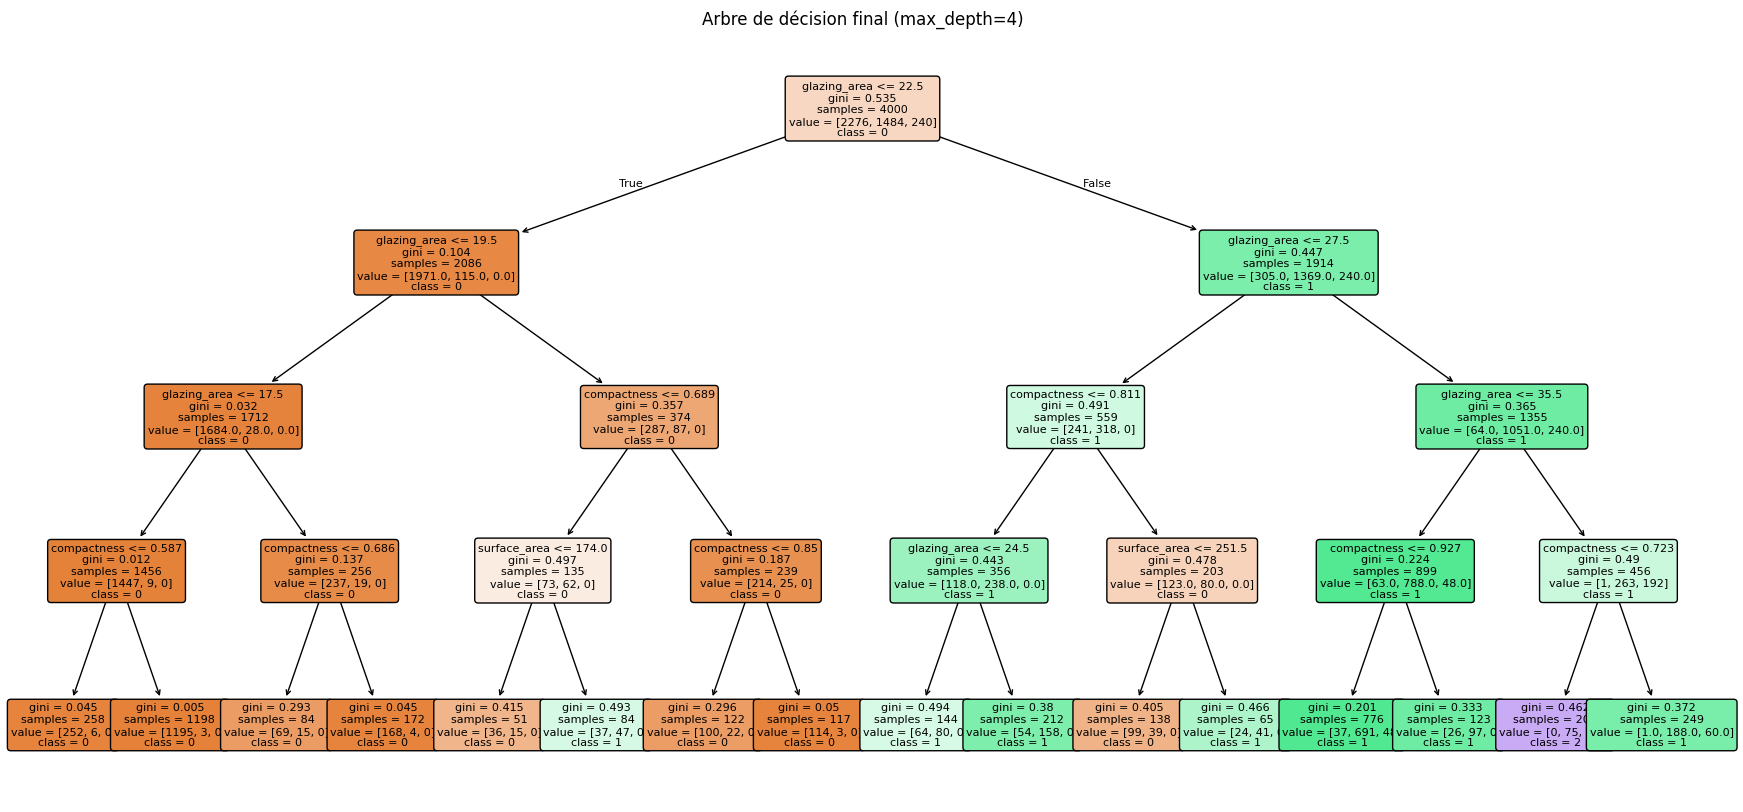

In [18]:
plt.figure(figsize=(22,10))
plot_tree(
    dt_final,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Arbre de décision final (max_depth={best_depth})")
plt.show()
